# WGISD: AP by Score Tertile

This notebook analyzes the WGISD dataset by difficulty-score tertile. It uses:

- a `score_results.json` file from the WGISD scoring run
- a YOLO weight file (`best.pt`)

It splits the image difficulty scores into 3 parts: low 30%, mid 30%, and top 30%. For each part, it evaluates the model on that subset and reports COCO AP and AP-by-size metrics.

Because WGISD annotations are YOLO text files, the object-profile statistics are computed directly from `train/labels` and the corresponding image sizes.

The final table includes the tertile mean and std of the difficulty scores, plus the AP results for each part.

In [6]:
from pathlib import Path
import json
import math
import os
import shutil
import sys
import tempfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

BASE_DIR = Path('/home/khanh/Projects/DifficultyAgri')
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

from dagri.baseline import Baseline
from dagri.interfaces import BaselineConfig, DatasetProperties, EvaluationConfig, TrainingConfig

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 180)

SCORE_PATH = BASE_DIR / 'results/055_multiseed_copy_paste_exp_wgisd_random/seed_123/Step_3_Scoring_Dataset/score_results.json'
WEIGHT_PATH = BASE_DIR / '.cache_result/no_trad_aug/wgisd/baseline/seed_123/best.pt'
DATA_ROOT = BASE_DIR / 'datasets/wgisd/yolo_format'
TRAIN_IMAGE_DIR = DATA_ROOT / 'train/images'
TRAIN_LABEL_DIR = DATA_ROOT / 'train/labels'
N_PARTS = 3
PART_LABELS = ['low_30', 'mid_30', 'top_30']
PREFIX_TO_VARIETY = {
    'CDY': 'Chardonnay',
    'CFR': 'Cabernet Franc',
    'CSV': 'Cabernet Sauvignon',
    'SVB': 'Sauvignon Blanc',
    'SYH': 'Syrah',
}

print('Score path exists:', SCORE_PATH.exists())
print('Weight path exists:', WEIGHT_PATH.exists())
print('Dataset root exists:', DATA_ROOT.exists())
print('Train image dir exists:', TRAIN_IMAGE_DIR.exists())
print('Train label dir exists:', TRAIN_LABEL_DIR.exists())

if not SCORE_PATH.exists():
    raise FileNotFoundError(f'Missing score file: {SCORE_PATH}')
if not WEIGHT_PATH.exists():
    raise FileNotFoundError(f'Missing weight file: {WEIGHT_PATH}')
if not TRAIN_IMAGE_DIR.exists() or not TRAIN_LABEL_DIR.exists():
    raise FileNotFoundError('Missing WGISD YOLO train images/labels directories')

with open(SCORE_PATH, 'r', encoding='utf-8') as f:
    score_data = json.load(f)

score_rows = []
for item in score_data.get('image_difficulties', []):
    image_path = item.get('image_path', '')
    if not image_path:
        continue
    score_rows.append({
        'image_name': Path(image_path).name,
        'image_path': image_path,
        'difficulty_score': float(item.get('difficulty_score', np.nan)),
        'num_objects': float(item.get('num_objects', np.nan)),
        'false_positive_rate': float(item.get('false_positive_rate', np.nan)),
        'missed_detections_rate': float(item.get('missed_detections_rate', np.nan)),
    })

score_df = pd.DataFrame(score_rows).dropna(subset=['image_name', 'difficulty_score']).copy()
score_df = score_df.drop_duplicates(subset=['image_name']).copy()
score_df['prefix'] = score_df['image_name'].str.split('_').str[0]
score_df['variety'] = score_df['prefix'].map(PREFIX_TO_VARIETY).fillna(score_df['prefix'])

q30 = score_df['difficulty_score'].quantile(0.30)
q70 = score_df['difficulty_score'].quantile(0.70)

def tertile_label(score: float) -> str:
    if score <= q30:
        return 'low_30'
    if score >= q70:
        return 'top_30'
    return 'mid_30'

score_df['score_tertile'] = score_df['difficulty_score'].apply(tertile_label)
score_df['score_tertile'] = pd.Categorical(score_df['score_tertile'], categories=PART_LABELS, ordered=True)

print(f'Loaded score rows: {len(score_df)}')
print(f'Low/mid threshold: {q30:.4f}')
print(f'Mid/top threshold: {q70:.4f}')
print(score_df.groupby('score_tertile').size().reindex(PART_LABELS).to_string())

Score path exists: True
Weight path exists: True
Dataset root exists: True
Train image dir exists: True
Train label dir exists: True
Loaded score rows: 193
Low/mid threshold: 0.0174
Mid/top threshold: 0.0218
score_tertile
low_30    58
mid_30    77
top_30    58


Variety share inside each tertile:
variety        Cabernet Franc  Cabernet Sauvignon  Chardonnay  Sauvignon Blanc  Syrah
score_tertile                                                                        
low_30                  0.190               0.328       0.190            0.069  0.224
mid_30                  0.325               0.221       0.182            0.091  0.182
top_30                  0.138               0.069       0.155            0.603  0.034

Majority variety inside each tertile:
  part   majority_variety  majority_variety_share  part_size
low_30 Cabernet Sauvignon                  0.3276         58
mid_30     Cabernet Franc                  0.3247         77
top_30    Sauvignon Blanc                  0.6034         58


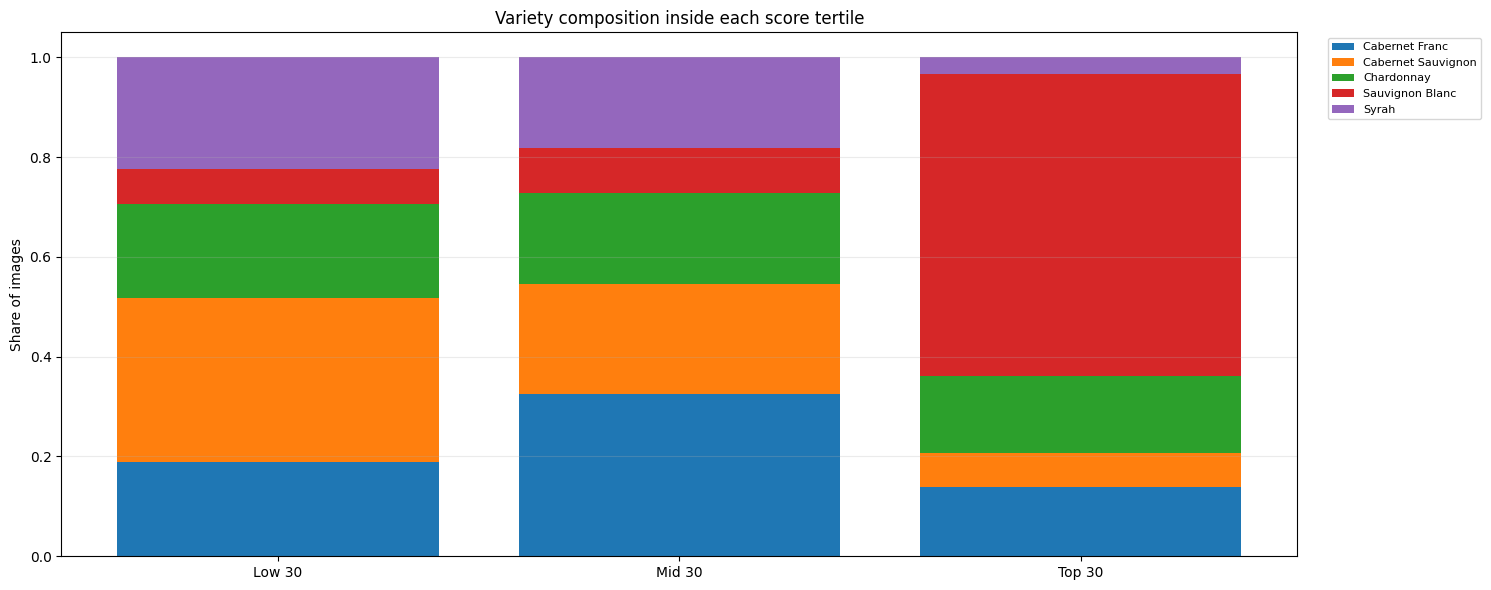

In [2]:
# Tertile composition by grape variety.
variety_counts_by_part = (
    score_df.groupby(['score_tertile', 'variety'])
    .size()
    .unstack(fill_value=0)
    .reindex(index=PART_LABELS, fill_value=0)
)
variety_share_by_part = variety_counts_by_part.div(variety_counts_by_part.sum(axis=1), axis=0).fillna(0)

majority_rows = []
for part in PART_LABELS:
    counts = variety_counts_by_part.loc[part].sort_values(ascending=False)
    top_variety = counts.index[0]
    top_share = float(counts.iloc[0] / counts.sum()) if counts.sum() else np.nan
    majority_rows.append({
        'part': part,
        'majority_variety': top_variety,
        'majority_variety_share': top_share,
        'part_size': int(counts.sum()),
    })

majority_df = pd.DataFrame(majority_rows)
print('Variety share inside each tertile:')
print(variety_share_by_part.round(3).to_string())
print()
print('Majority variety inside each tertile:')
print(majority_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

fig, ax = plt.subplots(figsize=(15, 6))
bottom = np.zeros(len(PART_LABELS))
x = np.arange(len(PART_LABELS))
for variety in variety_share_by_part.columns:
    vals = variety_share_by_part[variety].values
    ax.bar(x, vals, bottom=bottom, label=variety)
    bottom += vals
ax.set_xticks(x)
ax.set_xticklabels(['Low 30', 'Mid 30', 'Top 30'])
ax.set_ylabel('Share of images')
ax.set_title('Variety composition inside each score tertile')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

In [3]:
# Parse YOLO labels and compute object-profile statistics for each tertile.
def parse_yolo_label_file(image_path: Path, label_path: Path):
    if not label_path.exists():
        return []

    with Image.open(image_path) as image:
        image_width, image_height = image.size

    boxes = []
    for raw_line in label_path.read_text().splitlines():
        raw_line = raw_line.strip()
        if not raw_line:
            continue
        parts = raw_line.split()
        if len(parts) < 5:
            continue
        class_id = int(float(parts[0]))
        cx, cy, w, h = map(float, parts[1:5])
        width_px = w * image_width
        height_px = h * image_height
        area_px = width_px * height_px
        equiv_side = math.sqrt(area_px) if area_px > 0 else 0.0
        boxes.append({
            'class_id': class_id,
            'area_px': area_px,
            'equiv_side': equiv_side,
        })
    return boxes


def size_bucket_from_side(side_px: float) -> str:
    if side_px < 20:
        return 'very_small'
    if side_px < 32:
        return 'small'
    if side_px < 96:
        return 'medium'
    return 'large'


object_rows = []
for row in score_df.itertuples(index=False):
    image_path = Path(row.image_path)
    label_path = TRAIN_LABEL_DIR / f'{image_path.stem}.txt'
    boxes = parse_yolo_label_file(image_path, label_path)
    for box in boxes:
        object_rows.append({
            'image_name': row.image_name,
            'variety': row.variety,
            'area_px': box['area_px'],
            'equiv_side': box['equiv_side'],
            'size_bucket': size_bucket_from_side(box['equiv_side']),
        })

object_df = pd.DataFrame(object_rows)
object_df['size_bucket'] = pd.Categorical(object_df['size_bucket'], categories=['very_small', 'small', 'medium', 'large'], ordered=True)

image_object_stats = (
    object_df.groupby(['image_name', 'variety'])
    .agg(
        n_objects=('area_px', 'size'),
        mean_object_area=('area_px', 'mean'),
        mean_equiv_side=('equiv_side', 'mean'),
        pct_very_small=('size_bucket', lambda s: 100 * (s == 'very_small').mean()),
        pct_small=('size_bucket', lambda s: 100 * (s == 'small').mean()),
        pct_medium=('size_bucket', lambda s: 100 * (s == 'medium').mean()),
        pct_large=('size_bucket', lambda s: 100 * (s == 'large').mean()),
    )
    .reset_index()
)

image_tertile_df = score_df.merge(image_object_stats, on=['image_name', 'variety'], how='inner')

tertile_object_summary = image_tertile_df.groupby('score_tertile').agg(
    n_images=('image_name', 'count'),
    score_mean=('difficulty_score', 'mean'),
    score_std=('difficulty_score', 'std'),
    mean_objects=('n_objects', 'mean'),
    std_objects=('n_objects', 'std'),
    mean_object_area=('mean_object_area', 'mean'),
    std_object_area=('mean_object_area', 'std'),
    pct_very_small=('pct_very_small', 'mean'),
    pct_small=('pct_small', 'mean'),
    pct_medium=('pct_medium', 'mean'),
    pct_large=('pct_large', 'mean'),
).reindex(PART_LABELS)

print('Object profile by tertile:')
print(tertile_object_summary.round(4).to_string())

part_variety_detail = (
    image_tertile_df.groupby(['score_tertile', 'variety'])
    .agg(
        n_images=('image_name', 'count'),
        mean_score=('difficulty_score', 'mean'),
        mean_objects=('n_objects', 'mean'),
        mean_object_area=('mean_object_area', 'mean'),
        pct_very_small=('pct_very_small', 'mean'),
        pct_small=('pct_small', 'mean'),
        pct_medium=('pct_medium', 'mean'),
        pct_large=('pct_large', 'mean'),
    )
    .reset_index()
    .sort_values(['score_tertile', 'n_images'], ascending=[True, False])
)

for part in PART_LABELS:
    block = part_variety_detail[part_variety_detail['score_tertile'] == part].copy()
    block['share_in_part'] = block['n_images'] / block['n_images'].sum()
    print(f'\nTop varieties in {part}:')
    print(block[['variety', 'n_images', 'share_in_part', 'mean_score', 'mean_objects', 'mean_object_area', 'pct_very_small', 'pct_small', 'pct_medium', 'pct_large']].head(5).round(4).to_string(index=False))

Object profile by tertile:
               n_images  score_mean  score_std  mean_objects  std_objects  mean_object_area  std_object_area  pct_very_small  pct_small  pct_medium  pct_large
score_tertile                                                                                                                                                 
low_30               58      0.0157     0.0012       11.7759       3.9025        68344.1215       28593.6239          0.0000     0.0000      2.0566    97.9434
mid_30               77      0.0192     0.0013       14.5455       4.8055        41963.4586       15440.9871          0.0000     0.0000      5.2949    94.7051
top_30               58      0.0299     0.0174       18.9655       5.1571        24419.5178        8827.9426          0.3101     0.0907     16.7547    82.8445

Top varieties in low_30:
           variety  n_images  share_in_part  mean_score  mean_objects  mean_object_area  pct_very_small  pct_small  pct_medium  pct_large
Cabernet Sauvi

In [4]:
# Evaluate the baseline weight on each tertile subset using the repo's COCO evaluation path.
baseline_config = BaselineConfig(
    name='yolov8s',
    model_type='yolo',
    pretrained_weights_path=str(WEIGHT_PATH),
    training_config=TrainingConfig(
        epochs=1,
        batch_size=1,
        input_size=1024,
        learning_rate=0.01,
        seed=123,
        early_stopping_patience=1,
        traditional_augmentation_config={},
    ),
    evaluation_config=EvaluationConfig(
        image_size=1024,
        confidence_threshold=0.001,
        iou_threshold=0.5,
        max_detections=10000,
    ),
)

baseline_model = Baseline(baseline_config)

def link_or_copy(src: Path, dst: Path) -> None:
    dst.parent.mkdir(parents=True, exist_ok=True)
    if dst.exists() or dst.is_symlink():
        return
    try:
        dst.symlink_to(src)
    except OSError:
        shutil.copy2(src, dst)


def get_metric(eval_results, name: str) -> float:
    value = getattr(eval_results, name, np.nan)
    try:
        return float(value)
    except (TypeError, ValueError):
        return float('nan')


def evaluate_part(part_name: str, part_df: pd.DataFrame) -> dict:
    image_names = part_df['image_name'].tolist()
    image_path_by_name = score_df.set_index('image_name')['image_path'].to_dict()

    with tempfile.TemporaryDirectory(prefix=f'wgisd_{part_name}_') as tmp_dir:
        tmp_root = Path(tmp_dir)
        test_images_dir = tmp_root / 'test' / 'images'
        test_labels_dir = tmp_root / 'test' / 'labels'
        test_images_dir.mkdir(parents=True, exist_ok=True)
        test_labels_dir.mkdir(parents=True, exist_ok=True)

        for image_name in image_names:
            src_img = Path(image_path_by_name[image_name])
            src_lbl = TRAIN_LABEL_DIR / f'{src_img.stem}.txt'
            dst_img = test_images_dir / image_name
            dst_lbl = test_labels_dir / src_lbl.name
            link_or_copy(src_img, dst_img)
            link_or_copy(src_lbl, dst_lbl)

        dataset_props = DatasetProperties(
            root_dir=str(tmp_root),
            num_classes=1,
            class_names=['uva'],
            test_images_dir=str(test_images_dir),
            test_labels_dir=str(test_labels_dir),
        )

        eval_results = baseline_model.custom_evaluate_on_test_set(str(WEIGHT_PATH), dataset_props)

        return {
            'part': part_name,
            'n_images': len(image_names),
            'COCO_AP': get_metric(eval_results, 'COCO_AP'),
            'COCO_AP50': get_metric(eval_results, 'COCO_AP50'),
            'COCO_AP75': get_metric(eval_results, 'COCO_AP75'),
            'AP_small': get_metric(eval_results, 'AP_small'),
            'AP_medium': get_metric(eval_results, 'AP_medium'),
            'AP_large': get_metric(eval_results, 'AP_large'),
            'AP_very_small': get_metric(eval_results, 'AP_very_small'),
            'AP_small_20_32': get_metric(eval_results, 'AP_small_20_32'),
            'AP_medium_gt_32': get_metric(eval_results, 'AP_medium_gt_32'),
        }


eval_rows = []
for part in PART_LABELS:
    part_df = score_df[score_df['score_tertile'] == part].copy()
    print(f'Evaluating {part} with {len(part_df)} images...')
    eval_rows.append(evaluate_part(part, part_df))

eval_df = pd.DataFrame(eval_rows).set_index('part').reindex(PART_LABELS)
print('\nAP results by tertile:')
print(eval_df.round(4).to_string())

Evaluating low_30 with 58 images...
Ultralytics 8.4.21 🚀 Python-3.13.7 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Workstation Edition, 97248MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 6402.2±351.6 MB/s, size: 1081.2 KB)


/home/khanh/Projects/DifficultyAgri/venv/lib/python3.13/site-packages/torch/cuda/__init__.py:1007: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()


val: Scanning /tmp/wgisd_low_30_p9cjjsrj/test/labels... 58 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 58/58 1.3Kit/s 0.0s
val: New cache created: /tmp/wgisd_low_30_p9cjjsrj/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 15.6it/s 0.3s.1s
                   all         58        683      0.999      0.997      0.995      0.981
Speed: 0.6ms preprocess, 1.8ms inference, 0.0ms loss, 0.2ms postprocess per image
Saving /tmp/eval_test_t64y4hz2/evaluation/predictions.json...
Results saved to /tmp/eval_test_t64y4hz2/evaluation
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.05s).
Accumulating evaluation results...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.977
 Average Pr

Final summary table:
  part  part_size   majority_variety  majority_variety_share  score_mean  score_std  mean_objects  std_objects  mean_object_area  std_object_area  pct_very_small  pct_small  pct_medium  pct_large  COCO_AP  COCO_AP50  COCO_AP75  AP_very_small  AP_small  AP_small_20_32  AP_medium  AP_medium_gt_32  AP_large
low_30         58 Cabernet Sauvignon                  0.3276      0.0157     0.0012       11.7759       3.9025        68344.1215       28593.6239          0.0000     0.0000      2.0566    97.9434   0.9774     0.9995     0.9901            NaN   -1.0000             NaN     0.9916           0.9774    0.9766
mid_30         77     Cabernet Franc                  0.3247      0.0192     0.0013       14.5455       4.8055        41963.4586       15440.9871          0.0000     0.0000      5.2949    94.7051   0.9813     0.9901     0.9894            NaN   -1.0000             NaN     0.9848           0.9813    0.9813
top_30         58    Sauvignon Blanc                  0.6034 

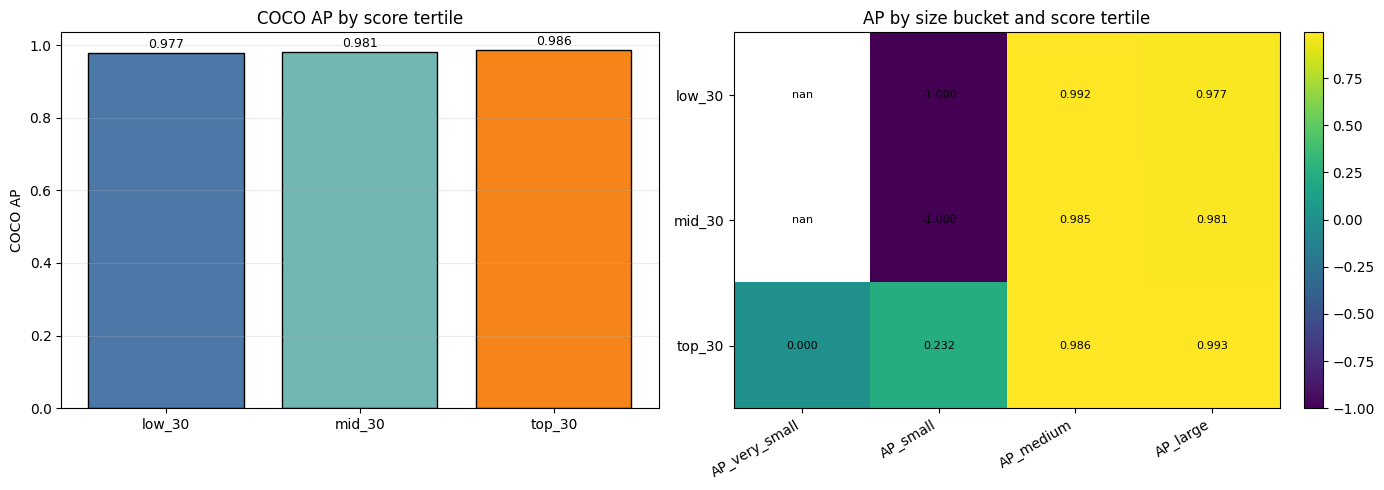


Interpretation:
- The majority variety tells you which grape cultivar dominates each tertile.
- The object-profile columns show whether the top tertile is driven by many small grapes, dense scenes, or both.
- The AP columns show the model quality on each tertile-specific subset.
- The heatmap makes it easy to compare whether top-score images are also the ones with weaker AP on tiny grapes.


In [5]:
# Final summary table: tertile mean/std plus AP results.
summary_df = majority_df.merge(tertile_object_summary.reset_index().rename(columns={'score_tertile': 'part'}), on='part', how='left')
summary_df = summary_df.merge(eval_df.reset_index().rename(columns={'part': 'part'}), on='part', how='left')
summary_df = summary_df[['part', 'part_size', 'majority_variety', 'majority_variety_share', 'score_mean', 'score_std', 'mean_objects', 'std_objects', 'mean_object_area', 'std_object_area', 'pct_very_small', 'pct_small', 'pct_medium', 'pct_large', 'COCO_AP', 'COCO_AP50', 'COCO_AP75', 'AP_very_small', 'AP_small', 'AP_small_20_32', 'AP_medium', 'AP_medium_gt_32', 'AP_large']]

print('Final summary table:')
print(summary_df.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(summary_df['part'], summary_df['COCO_AP'], color=['#4c78a8', '#72b7b2', '#f58518'], edgecolor='black')
axes[0].set_ylabel('COCO AP')
axes[0].set_title('COCO AP by score tertile')
axes[0].grid(axis='y', alpha=0.25)
for idx, val in enumerate(summary_df['COCO_AP']):
    axes[0].text(idx, val + 0.005, f'{val:.3f}', ha='center', va='bottom', fontsize=9)

metrics_to_plot = ['AP_very_small', 'AP_small', 'AP_medium', 'AP_large']
metric_table = summary_df.set_index('part')[metrics_to_plot]
im = axes[1].imshow(metric_table.values, aspect='auto', cmap='viridis')
axes[1].set_xticks(range(len(metrics_to_plot)))
axes[1].set_xticklabels(metrics_to_plot, rotation=30, ha='right')
axes[1].set_yticks(range(len(summary_df)))
axes[1].set_yticklabels(summary_df['part'])
axes[1].set_title('AP by size bucket and score tertile')
for i in range(metric_table.shape[0]):
    for j in range(metric_table.shape[1]):
        axes[1].text(j, i, f'{metric_table.values[i, j]:.3f}', ha='center', va='center', color='white' if metric_table.values[i, j] < metric_table.values.max() * 0.6 else 'black', fontsize=8)
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

print('\nInterpretation:')
print('- The majority variety tells you which grape cultivar dominates each tertile.')
print('- The object-profile columns show whether the top tertile is driven by many small grapes, dense scenes, or both.')
print('- The AP columns show the model quality on each tertile-specific subset.')
print('- The heatmap makes it easy to compare whether top-score images are also the ones with weaker AP on tiny grapes.')